In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import hsv_to_rgb

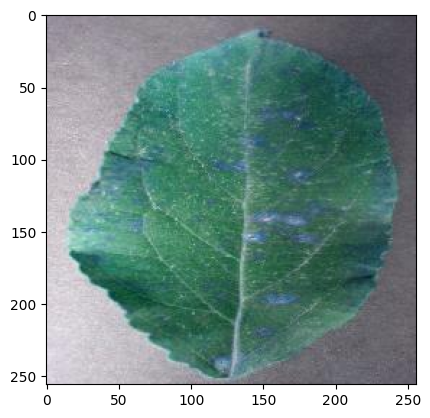

In [2]:
img = cv2.imread('./image.jpg')
plt.imshow(img)
plt.show()

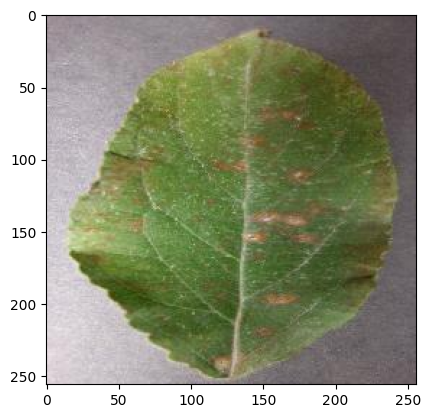

In [3]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

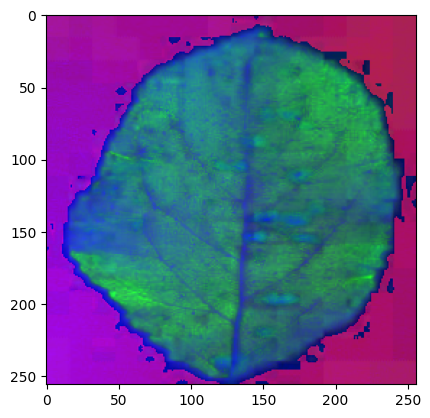

In [4]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
plt.imshow(hsv_img)

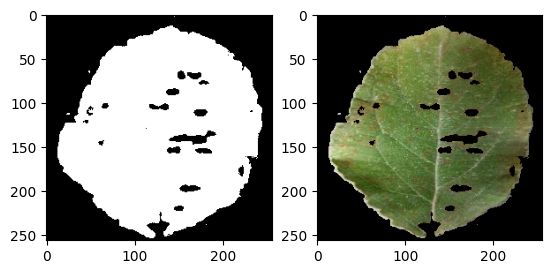

In [5]:
lower_green = np.array([25,0,20])
upper_green = np.array([100,255,255])
mask = cv2.inRange(hsv_img, lower_green, upper_green)
result = cv2.bitwise_and(img, img, mask=mask)
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(result)
plt.show()

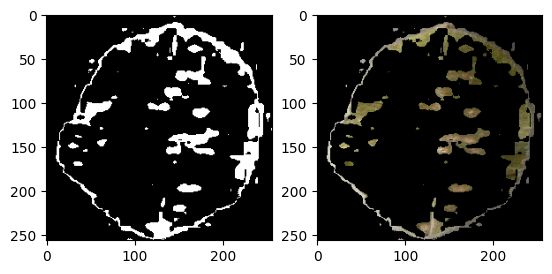

In [6]:
lower_brown = np.array([10,0,10])
upper_brown = np.array([30,255,255])
disease_mask = cv2.inRange(hsv_img, lower_brown, upper_brown)
disease_result = cv2.bitwise_and(img, img, mask=disease_mask)
plt.subplot(1, 2, 1)
plt.imshow(disease_mask, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(disease_result)
plt.show()

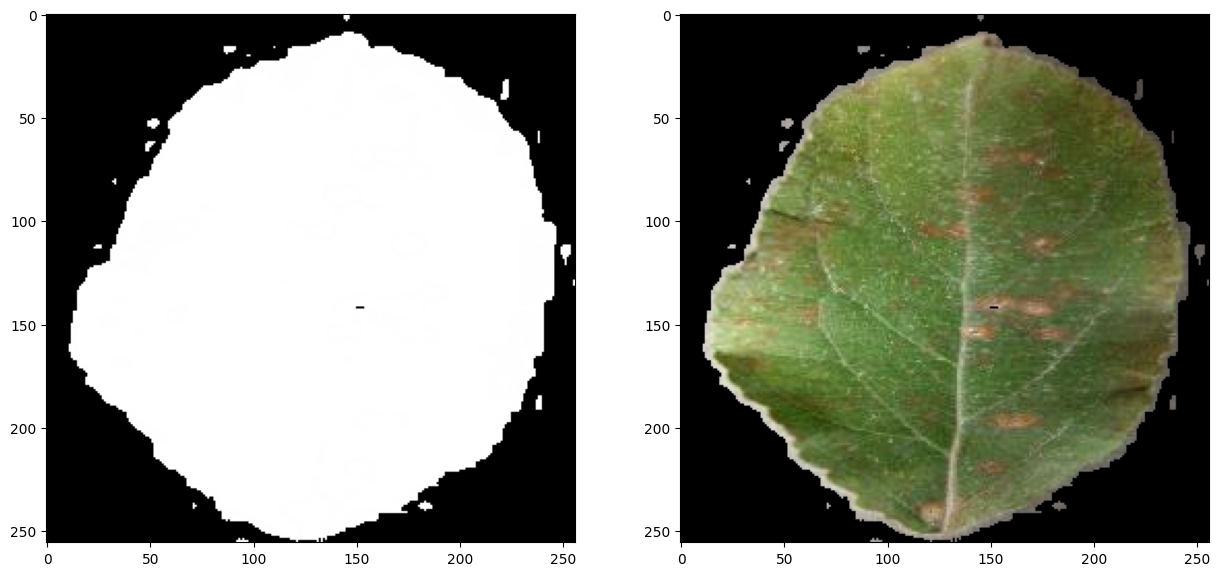

In [7]:
final_mask = mask + disease_mask
final_result = cv2.bitwise_and(img, img, mask=final_mask)
plt.figure(figsize=(15,15))
plt.subplot(1, 2, 1)
plt.imshow(final_mask, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(final_result)
plt.show()

In [8]:
# Feature Descripotor

orb = cv2.ORB_create()
kp, des = orb.detectAndCompute(final_result, None)
len(kp)

328

In [9]:
print(kp)

(< cv2.KeyPoint 0000016725877F00>, < cv2.KeyPoint 000001672365A6A0>, < cv2.KeyPoint 000001672365BF00>, < cv2.KeyPoint 0000016723057150>, < cv2.KeyPoint 00000167258370F0>, < cv2.KeyPoint 00000167233EF1B0>, < cv2.KeyPoint 00000167236019B0>, < cv2.KeyPoint 0000016723600810>, < cv2.KeyPoint 00000167235AEB80>, < cv2.KeyPoint 00000167235AD0E0>, < cv2.KeyPoint 00000167235AE9A0>, < cv2.KeyPoint 0000016723525950>, < cv2.KeyPoint 00000167258E27C0>, < cv2.KeyPoint 00000167231B10E0>, < cv2.KeyPoint 00000167258CB3C0>, < cv2.KeyPoint 00000167258C9590>, < cv2.KeyPoint 00000167258C8CF0>, < cv2.KeyPoint 00000167258C9320>, < cv2.KeyPoint 00000167258CBD80>, < cv2.KeyPoint 00000167258CBD20>, < cv2.KeyPoint 00000167258C8870>, < cv2.KeyPoint 00000167258C9410>, < cv2.KeyPoint 00000167258C92F0>, < cv2.KeyPoint 00000167258C9BF0>, < cv2.KeyPoint 00000167258C90E0>, < cv2.KeyPoint 00000167258A94A0>, < cv2.KeyPoint 00000167258A90E0>, < cv2.KeyPoint 00000167258AB9C0>, < cv2.KeyPoint 00000167258A9530>, < cv2.KeyPoin

In [10]:
print(des)

[[ 90  34 114 ... 132  90 133]
 [ 50   1  38 ...  14  61 134]
 [ 80   0  46 ...   8 124 198]
 ...
 [214 255 155 ... 115 135 101]
 [205  36 152 ...  80 139  40]
 [249 199  44 ... 166  90  76]]


In [11]:
img2 = cv2.drawKeypoints(final_result,kp,None,(255,0,0),4)

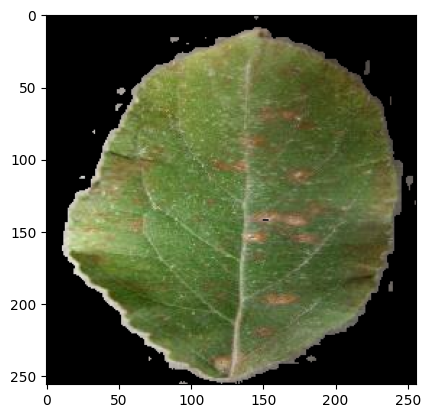

In [12]:
plt.imshow(final_result)


In [13]:
# global Feature
global_feature = des

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
rescaled_features = scaler.fit_transform(global_feature)

In [15]:
global_feature.shape

(328, 32)

In [16]:
orb.descriptorSize()

32

In [17]:
print("[STATUS] feature vector size {}".format(np.array(global_feature).shape))


[STATUS] feature vector size (328, 32)


In [18]:
a = global_feature
np.savetxt("doo.csv", a, delimiter=",")